## Pydantic Schema

In [9]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv
load_dotenv()



llm = ChatGoogleGenerativeAI(
    model="gemini-flash-lite-latest",
    temperature=0.7,
    google_api_key=os.environ["GOOFLE_API_KEY"]
)

In [10]:
response = llm.invoke("meaning of water")
print(response.content)


[{'type': 'text', 'text': 'The word **water** is broad because it functions as a noun, a verb, and a fundamental concept in science, culture, and biology. Here is a breakdown of its meanings:\n\n### 1. Scientific Definition (The Physical Substance)\nScientifically, water is a transparent, tasteless, odorless, and nearly colorless chemical substance that is the main constituent of Earth\'s hydrosphere and the fluids of all known living organisms.\n*   **Chemical Formula:** $H_2O$ (two hydrogen atoms covalently bonded to one oxygen atom).\n*   **Physical States:** It is unique because it exists naturally on Earth in three states: liquid (water), solid (ice), and gas (water vapor).\n*   **Role in Life:** It is often called the "universal solvent" because it can dissolve more substances than any other liquid. It is essential for all known forms of life.\n\n### 2. Common Usage (Noun)\n*   **The Beverage:** "I’d like a glass of water, please."\n*   **Bodies of Water:** Referring to oceans, s

In [11]:
from pydantic import BaseModel,Field


class graph_schema(BaseModel):
    topic : str = Field(description = "Topic of the Graph")
    post : str = Field(description="The content of Linkedin Post")
    curated_post :str = Field(description="The curated Linked in Post")


demo_obj = graph_schema(
    topic = " impostance of digital marketing",
    post = "its very important",
    curated_post = "in the digital post masses are commmuicated"
)

In [12]:
print(demo_obj)

topic=' impostance of digital marketing' post='its very important' curated_post='in the digital post masses are commmuicated'


In [13]:
def create_post(state: graph_schema) -> dict:
    topic = state.topic

    response = llm.invoke(f"Write a LinkedIn post about {topic}")
    content = response.content
    if isinstance(content, list):
        content = "".join(block.get("text", "") for block in content if isinstance(block, dict) and block.get("type") == "text")
    
    return {"post": content}

def curated_post(state : graph_schema) -> dict:
    post = state.post

    response = llm.invoke(f"Curate the following LinkedIn post with Genz tone: {post}")
    content = response.content
    if isinstance(content, list):
        content = "".join(block.get("text", "") for block in content if isinstance(block, dict) and block.get("type") == "text")
    
    return {"curated_post": content}

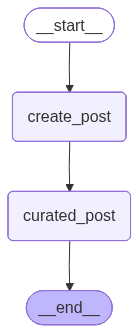

In [14]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(graph_schema)
graph.add_node("create_post",create_post)
graph.add_node("curated_post",curated_post)

graph.add_edge(START,"create_post")
graph.add_edge("create_post","curated_post")
graph.add_edge("curated_post",END)

pydantic_graph = graph.compile()

from IPython.display import Image,display

Image(pydantic_graph.get_graph().draw_mermaid_png())

In [15]:
result = pydantic_graph.invoke(
    {
        "topic": "The importance of data privacy in the digital age",
        "post": "",
        "curated_post": ""
    }
)

print(result)

{'topic': 'The importance of data privacy in the digital age', 'post': 'Here are three options for your LinkedIn post, depending on the tone you want to strike:\n\n### Option 1: The "Thought Leader" approach (Professional & Insightful)\n**Headline: Data is the new currency, but privacy is the vault.**\n\nIn an era where every click, scroll, and purchase is tracked, we often treat our personal data as a small price to pay for convenience. But we need to shift our mindset: Data privacy isn’t just a "compliance" issue—it’s a fundamental human right.\n\nAs we continue to integrate AI and hyper-personalized tech into our daily lives, the gap between innovation and protection is widening. \n\nFor businesses, privacy is no longer just about avoiding fines (though GDPR and CCPA are critical). It’s about **trust.** \n\nConsumers are becoming more savvy. They aren’t just looking for the best product; they are looking for the brand that respects their digital boundaries. Transparency is the new c